# Beam Mapping — Module Test

Runs the beam-mapping pipeline using the `eigsep_data` package API
instead of inline function definitions (the original inline notebook
this replicated has been removed now that this one reproduces it).
Uses the same data and magic numbers so results can be compared directly.

In [ ]:
# import sys                                                                                                            
# sys.path.insert(0, '/Users/dominiv/eigsep/data-analysis/src')
import sys
sys.path.insert(0, '/Users/dominiv/eigsep/data-analysis/src') 
import picohost                                                                                                       
if not hasattr(picohost.PicoRFSwitch, 'path_str'):                                                                    
      picohost.PicoRFSwitch.path_str = {}  # stub for older picohost     
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import jax
import jax.numpy as jnp
from pathlib import Path
from datetime import datetime, timezone
from scipy.ndimage import binary_dilation

import eigsep_data
from eigsep_data import (
    beam_sim,
    beam_fit,
    rfi,
    plot as eplot,
)
from eigsep_data.data import (
    to_unix_time,
    extract_clean_pot_data_v2,
    extract_beam_mapping_data,
    calibrate_weak_arm,
)
from eigsep_data.hpm import sph_fit
from eigsep_data.rfi import (
    flag_rfi_time,
    fit_dpss_model_per_time,
    fit_dpss_interleaved_fix,
)
from eigsep_data.plot import (
    plot_dpss_fit_examples,
    summarize_dpss_reduction,
)
from eigsep_data.beam_sim import (
    read_beam,
    simulate_both_arms_interleaved,
)
from eigsep_data.beam_fit import fit_multi_freq_joint

jax.config.update("jax_enable_x64", True)
%matplotlib widget

## Configuration

In [ ]:
path          = '/Users/dominiv/research/data/deployment5_filtered/'
data_dir      = Path(path)
file_patterns = ['*.h5', '*.hdf5']

start_time = '2026-07-17 20:26:00'
end_time   = '2026-07-17 21:28:00'

# HFSS bowtie beam paths default to hfss_beam_maps/ in the repo (see
# beam_sim.read_beam); no override needed unless testing another beam.

## Load Data

In [ ]:
start_unix = to_unix_time(start_time)
end_unix   = to_unix_time(end_time)

if end_unix <= start_unix:
    raise ValueError('end_time must be later than start_time.')

# Time slice: strip sweep at the start; applied to every per-sample array
# returned by extract_beam_mapping_data.
sl = slice(55 + 64, 55 + 4939 + 1)

extracted = extract_beam_mapping_data(
    data_dir, start_time, end_time,
    file_patterns=tuple(file_patterns),
    sweep_slice=sl,
)

print(f'Directory:             {data_dir}')
print(f'Selected integrations: {len(extracted["times"])}')
print(f'First sample: {datetime.fromtimestamp(extracted["times"][0], tz=timezone.utc)}')
print(f'Last sample:  {datetime.fromtimestamp(extracted["times"][-1], tz=timezone.utc)}')

## Load HFSS Beam Maps

In [ ]:
# Cartesian E-field beams (used for forward simulation + fitting),
# spherical gain components (used for HFSS truth maps), and each
# slice's frequency (MHz, on the same grid as the correlator freqs)
bowtie_beams_use, gain_maps_sph, beam_freqs = read_beam()

print('bowtie_beams_use shape:', bowtie_beams_use.shape)
print('gain_maps_sph shape:   ', gain_maps_sph.shape)
print('beam_freqs shape:      ', beam_freqs.shape)

## Extract Sky / Ground Arrays and Run DPSS Reduction

In [ ]:
freqs   = extracted['freqs']
chs_use = np.arange(8, 1024, 8)

sky    = extracted['sky']
ground = extracted['ground']
cross  = extracted['cross']

# Simple comb reduction for comparison
reduced      = sky[:, chs_use] - 0.5 * (sky[:, chs_use - 1] + sky[:, chs_use + 1])
test_data    = reduced / np.mean(reduced, axis=0)

dpss_rot = fit_dpss_model_per_time(
    raw=sky,
    chs=chs_use,
    freqs=freqs,
    nw=4.0,
    nterms=32,
    include_poly=True,
    poly_order=2,
    guard_bins=1,
    fit_min_chan=min(chs_use) - 8,
    fit_max_chan=sky.shape[1],
    use_log=True,
    ridge=1e-5,
    verbose=True,
)

dpss_ground = fit_dpss_model_per_time(
    raw=ground,
    chs=chs_use,
    freqs=freqs,
    nw=4.0,
    nterms=32,
    include_poly=True,
    poly_order=2,
    guard_bins=1,
    fit_min_chan=min(chs_use) - 8,
    fit_max_chan=sky.shape[1],
    use_log=True,
    ridge=1e-5,
    verbose=True,
)

rot_dpss    = dpss_rot['reduced']
ground_dpss = dpss_ground['reduced']

summarize_dpss_reduction(dpss_out=dpss_rot, test_data_skyavg=test_data, rfi_bad=[0])

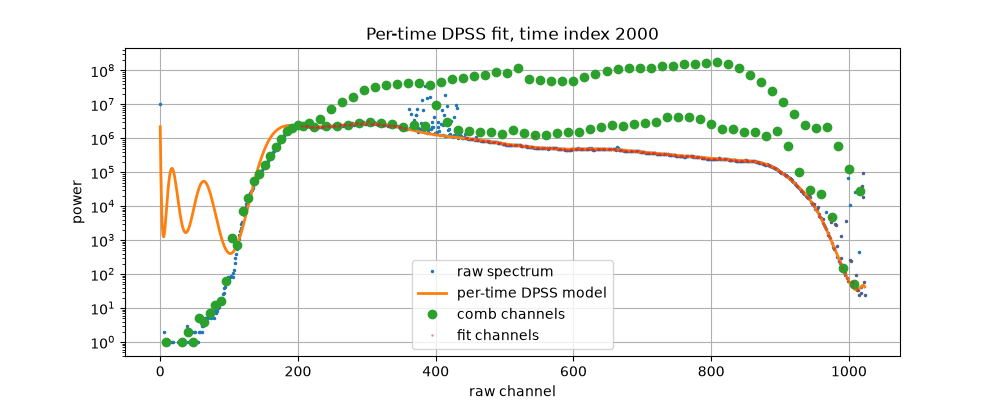

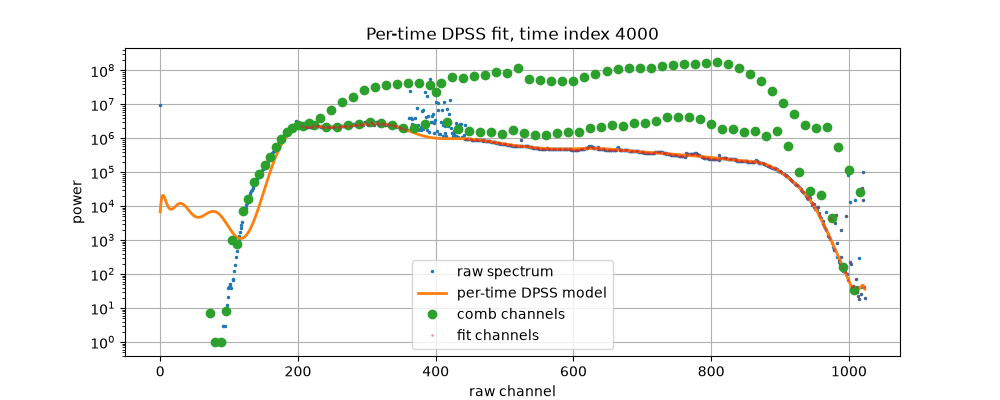

In [7]:
plot_dpss_fit_examples(raw=sky,    dpss_out=dpss_rot,    times_to_plot=(0, 2000, 4000), yscale='log')
plot_dpss_fit_examples(raw=ground, dpss_out=dpss_ground, times_to_plot=(0, 2000, 4000), yscale='log')

## Clean Potentiometer Azimuth

In [ ]:
az_step    = extracted['az_pos'] / (113 / 1.8)
az_pot_raw = np.copy(extracted['pot_az_angle'])
az_pot     = extract_clean_pot_data_v2(az_pot_raw, az_step)

# Choose which angle source to use
az_deg = az_pot.copy()
el_deg = extracted['imu_el_deg'].copy()

## Prepare DPSS-Reduced Data

/Users/dominiv/eigsep/data-analysis/src/eigsep_data/data.py:288: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


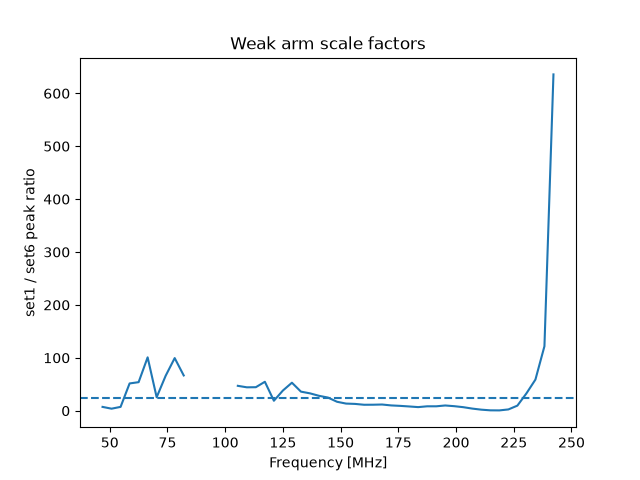

In [12]:
dpss_red      = rot_dpss.copy()
ground_dpss_r = dpss_ground['reduced']

# Calibrate weak arm and correct
scale_factors, peak_powers = calibrate_weak_arm(el_deg, az_deg, dpss_red)
dpss_red_corrected              = dpss_red.copy()
dpss_red_corrected[:, 1::2]    *= scale_factors

plt.figure()
plt.plot(freqs[::8][::2][:-1], scale_factors)
plt.axhline(25, linestyle='--')
plt.ylabel('set1 / set6 peak ratio')
plt.xlabel('Frequency [MHz]')
plt.title('Weak arm scale factors')
plt.show()

## Shift, Split, and Interleaved DPSS Fit

In [13]:
shift_new = 27
rot_masked        = dpss_red_corrected[:, shift_new:]
dpss_red_masked   = rot_masked.copy()
dpss_red_ground   = ground_dpss_r[:, shift_new:]

# RFI flagging and baseline replacement
P_meas = np.copy(dpss_red_masked)
rfi_mask, baseline, residual = flag_rfi_time(
    P_meas,
    window=21,
    sigma=16.0,
    floor_fraction=0.1,
)

rfi_mask_expanded         = binary_dilation(rfi_mask, structure=np.ones((3, 1), dtype=bool))
P_clean                   = P_meas.copy()
P_clean[rfi_mask_expanded] = baseline[rfi_mask_expanded]

Px_hat, Py_hat, G_hat, bad_time, rfi_occupancy = fit_dpss_interleaved_fix(
    P_clean,
    freqs[::8][shift_new:-1],
    nmodes=23,
    NW=4.0,
)

print('Px_hat shape:', Px_hat.shape)
print('Py_hat shape:', Py_hat.shape)
print('G_hat shape: ', G_hat.shape)

/Users/dominiv/eigsep/data-analysis/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Px_hat shape: (4876, 100)
Py_hat shape: (4876, 100)
G_hat shape:  (4876, 100)


## Multi-Frequency Joint Fit (TX position + polarization)

In [29]:
# Select HFSS beam indices and corresponding data columns.
# Py_hat columns are indexed from the interleaved output;
# data_indices are odd → maps to alpha+90° arm in the loss function.
my_freq_map = [(i, i // 2) for i in range(60, 90)]
                                                                                                                      
# Build P_meas_for_fit: column d_idx holds the normalized data for that channel.                                      
# Even d_idx → Px_hat arm, odd d_idx → Py_hat arm.
# Within each arm array, column index is d_idx // 2.                                                                  
n_cols         = max(d for d, _ in my_freq_map) + 1                                                                   
P_meas_for_fit = np.zeros((len(az_deg), n_cols))
                                                                                                                      
for d_idx, _ in my_freq_map:                                                                                          
    col_data = Px_hat[:, d_idx // 2] if d_idx % 2 == 0 else Py_hat[:, d_idx // 2]
    mean     = np.mean(col_data)                                                                                      
    P_meas_for_fit[:, d_idx] = col_data / mean if mean != 0 else col_data
                                                                                                                      
stride        = 10
P_meas_fast   = P_meas_for_fit[::stride]                                                                              
az_fast       = az_deg[::stride]                          
el_fast       = el_deg[::stride]

(
    local_result,
    best_coord,                                                                                                       
    best_x, best_y,
    best_alpha,                                                                                                       
    loss_2d,                                              
    extent,
) = fit_multi_freq_joint(                                                                                             
    P_meas=P_meas_fast,
    bowtie_beams_use=bowtie_beams_use,                                                                                
    az_deg=az_fast,                                       
    el_deg=el_fast,
    freq_map=my_freq_map,
    theta_bounds=(90.0, 180.0),                                                                                       
    phi_bounds=(0.0, 360.0),
    alpha_bounds=(0.0, 180.0),                                                                                        
    fit_offset=True,                                      
    seed=0,                                                                                                           
    xy_bounds=(-1.0, 1.0),
    grid_res=0.04,                                                                                                    
)                                                         

best_theta, best_phi, _ = local_result.x                                                                              
print(f'Best theta: {best_theta:.4f}°')
print(f'Best phi:   {best_phi:.4f}°')                                                                                 
print(f'Best alpha: {best_alpha:.4f}°')                                                                               
print(f'Best coord [x, y, z]: {best_coord}')

Generating 51x51 Cartesian loss map at alpha = 133.93°...
Best theta: 174.0581°
Best phi:   249.9310°
Best alpha: 133.9319°
Best coord [x, y, z]: [-0.03552299 -0.09723427 -0.99462737]


In [54]:
my_freq_map = [(i, i // 2) for i in range(60, 90)]
                                                                                                                        
# Normalize each channel by its time-mean                                                                             
P_norm = P_meas / np.mean(P_meas, axis=0)
                                                                                                                      
# stride       = 10                                         
stride       = 1
P_meas_fast  = P_norm[::stride]
az_fast      = az_deg[::stride]
el_fast      = el_deg[::stride]                                                                                       

(                                                                                                                     
    local_result,                                         
    best_coord,
    best_x, best_y,
    best_alpha,
    loss_2d,
    extent,
) = fit_multi_freq_joint(
    P_meas=P_meas_fast,
    bowtie_beams_use=bowtie_beams_use,
    az_deg=az_fast,                                                                                                   
    el_deg=el_fast,
    freq_map=my_freq_map,                                                                                             
    theta_bounds=(90.0, 180.0),                           
    phi_bounds=(0.0, 360.0),
    alpha_bounds=(0.0, 180.0),
    fit_offset=True,
    seed=0,                                                                                                           
    xy_bounds=(-1.0, 1.0),
    grid_res=0.04,                                                                                                    
)     
best_theta, best_phi, _ = local_result.x                                                                              
print(f'Best theta: {best_theta:.4f}°')
print(f'Best phi:   {best_phi:.4f}°')                                                                                 
print(f'Best alpha: {best_alpha:.4f}°')                                                                               
print(f'Best coord [x, y, z]: {best_coord}')

Generating 51x51 Cartesian loss map at alpha = 133.59°...
Best theta: 172.0215°
Best phi:   228.6967°
Best alpha: 133.5926°
Best coord [x, y, z]: [-0.09161514 -0.10427131 -0.99032023]


In [ ]:
# Cartesian loss map
# fig, ax = plt.subplots(figsize=(8, 8))
# im = ax.imshow(
#     np.log10(loss_2d),
#     extent=extent,
#     origin='lower',
#     aspect='equal',
#     cmap='viridis',
# )
# plt.colorbar(im, ax=ax, label='Log10(MSE loss)')
# ax.scatter(best_x, best_y, color='red', marker='x', s=100, linewidth=2,
#            label=f'Best fit ({best_x:.3f}, {best_y:.3f})')
# circle = plt.Circle((0, 0), 1.0, color='white', fill=False,)
#                      # linestyle='--', linewidth=1.5, label='Unit sphere')
# ax.add_patch(circle)
# ax.set_xlim(-1.1, 1.1)
# ax.set_ylim(-1.1, 1.1)
# ax.set_title(f'Cartesian loss map  (alpha = {best_alpha:.1f}°)')
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
# Cartesian loss map
h_meters = 92.5

# 1. Scale the bounding box and the best-fit coordinates
extent_meters = [val * h_meters for val in extent]
best_x_m = best_x * h_meters
best_y_m = best_y * h_meters

# 2. Plot the X-Y Landscape
plt.figure(figsize=(8, 8))

im = plt.imshow(
    # np.log10(loss_2d), 
    loss_2d, 
    extent=extent_meters,  # <-- Passed scaled extent here
    origin='lower',
    aspect='equal', 
    cmap='viridis',
    # vmin=5, vmax=15,
)
plt.colorbar(im, label='Log10(Mean MSE Loss)')
# plt.colorbar(im, label='Mean MSE Loss')

# Overlay the scaled best fit point
plt.scatter(
    best_x_m, best_y_m, 
    color='red', marker='x', s=100, linewidth=2, 
    label=f'Best Fit ({best_x_m:.1f} m, {best_y_m:.1f} m)'
)

# Draw the boundary circle scaled to 100 meters
circle = plt.Circle(
    (0, 0), 
    1.0 * h_meters, 
    color='white', fill=False, linestyle='--', linewidth=1.5, 
    # label='100m Radius Bound'
)
plt.gca().add_patch(circle)

# Scale the axis limits to give a 10% padding (110 meters)
plt.xlim(-1.1 * h_meters, 1.1 * h_meters)
plt.ylim(-1.1 * h_meters, 1.1 * h_meters)
# plt.xlim(-20, 20)
# plt.ylim(-20, 20)

plt.title(f"Cartesian Position Loss (X vs Y | Optimized Alpha = {best_alpha:.1f}°)")
plt.xlabel("X Position (meters)")
plt.ylabel("Y Position (meters)")
plt.legend(loc='upper right')
plt.show()

## Forward Simulate All Frequencies

In [61]:
sim_all_freqs_raw, pxs_all_freqs_raw = simulate_both_arms_interleaved(
    bowtie_beams_use=bowtie_beams_use,
    az_deg=az_deg,
    el_deg=el_deg,
    coord=best_coord,
    # alpha=best_alpha - 90,  # note: alpha convention — validate on real data
    alpha=best_alpha,  # note: alpha convention — validate on real data
)

# Transpose to (n_measurements, n_frequencies)
sim_all_freqs_raw = sim_all_freqs_raw.T

print('sim_all_freqs_raw shape:  ', sim_all_freqs_raw.shape)
print('pxs_all_freqs_raw shape:  ', pxs_all_freqs_raw.shape)

sim_all_freqs_raw shape:   (4876, 102)
pxs_all_freqs_raw shape:   (102, 4876)


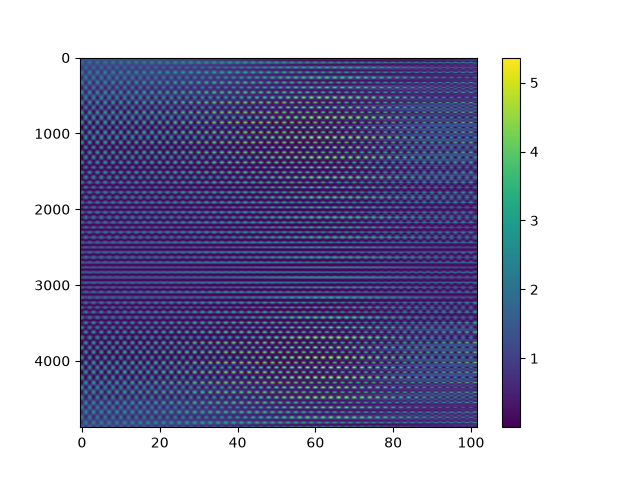

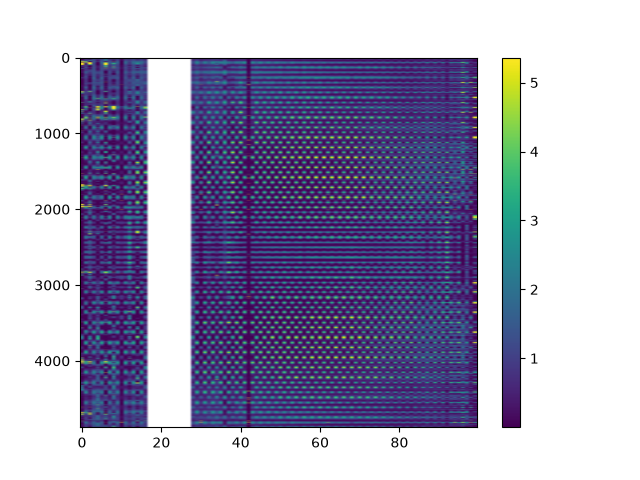

In [62]:
plt.figure()
plt.imshow(sim_all_freqs_raw, aspect='auto')
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(P_meas/np.mean(P_meas, axis=0), aspect='auto', vmax=np.max(sim_all_freqs_raw), vmin=np.min(sim_all_freqs_raw))
plt.colorbar()
plt.show()

## Scatter Plots — Data vs HFSS

In [ ]:
ind      = 65   # interleaved channel index
ind_hfss = 34   # HFSS beam index (beam_freqs[ind_hfss] ~= 179.7 MHz)
lam      = 1e-3
lmax     = 5

Px_mean  = Px_hat[:, ind] / np.mean(Px_hat[:, ind])
Py_mean  = Py_hat[:, ind] / np.mean(Py_hat[:, ind])
dpss_gain = Px_mean + Py_mean
dpss_norm = dpss_gain / np.max(dpss_gain)

freq_label = f'{freqs[::8][27:-1][ind]:.1f} MHz'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

sc1 = axes[0].scatter(el_deg, az_deg, c=dpss_norm, s=25, cmap='plasma')
axes[0].set_title(f'Total gain data {freq_label}')
fig.colorbar(sc1, ax=axes[0]).set_label('Normalized gain')

test_hfss = gain_maps_sph[ind_hfss, pxs_all_freqs_raw[ind]]
sc2 = axes[1].scatter(el_deg, az_deg, c=test_hfss, s=25, cmap='plasma')
axes[1].set_title(f'Total gain HFSS {freq_label}')
fig.colorbar(sc2, ax=axes[1]).set_label('Normalized gain')

sc3 = axes[2].scatter(el_deg, az_deg, c=(test_hfss - dpss_norm), s=25,
                      cmap='bwr', vmin=-0.2, vmax=0.2)
axes[2].set_title('Difference (HFSS − Data)')
fig.colorbar(sc3, ax=axes[2]).set_label('Difference')

for ax in axes:
    ax.set_xlabel('el [deg]')
    ax.set_ylabel('az [deg]')

# plt.tight_layout()
plt.show()

## Spherical Harmonic Beam Reconstruction

In [64]:
nside     = 32
empty_map = np.full_like(bowtie_beams_use[0, 0], fill_value=hp.UNSEEN, dtype=float)

valid = (
    ~rfi_mask[:, ind]
    & np.isfinite(Py_hat[:, ind] + Px_hat[:, ind])
)

empty_map[pxs_all_freqs_raw[ind][valid]] = G_hat[valid, ind]

# HFSS truth on the same pixels
gain_maps = np.sum(np.abs(bowtie_beams_use) ** 2, axis=1)
gain_maps = gain_maps / np.max(gain_maps, axis=1, keepdims=True)

unseen_rec = np.full_like(empty_map, fill_value=hp.UNSEEN)
unseen_rec[pxs_all_freqs_raw[ind]] = gain_maps[ind_hfss][pxs_all_freqs_raw[ind]]

rec_truth = sph_fit(unseen_rec, nside=nside, lmax=lmax, lam=lam)

vmin = np.min(rec_truth[0] / np.max(rec_truth[0]))
vmax = np.max(rec_truth[0] / np.max(rec_truth[0]))

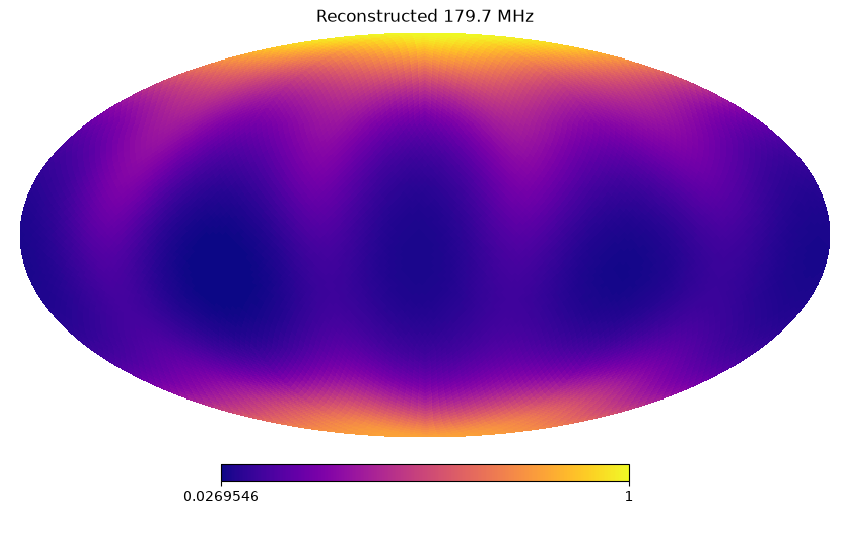

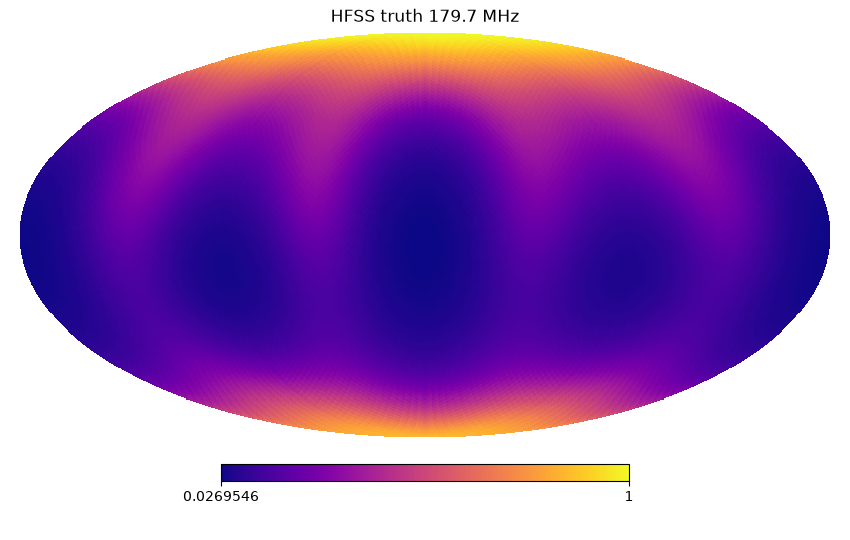

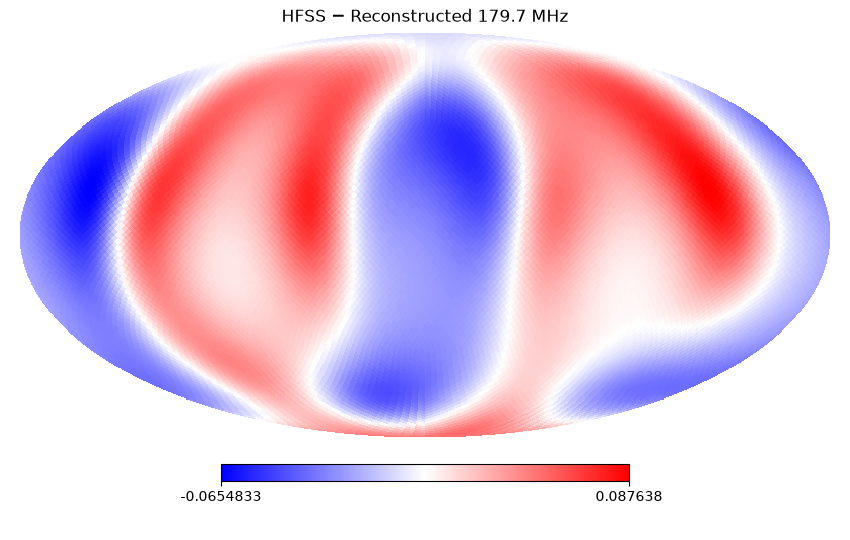

In [65]:
rec_maps = sph_fit(empty_map, nside=nside, lmax=lmax, lam=lam)

hp.mollview(rec_maps[0] / np.max(rec_maps[0]),  cmap='plasma', title=f'Reconstructed {freq_label}',  min=vmin, max=vmax)
plt.show()
hp.mollview(rec_truth[0] / np.max(rec_truth[0]), cmap='plasma', title=f'HFSS truth {freq_label}',    min=vmin, max=vmax)
plt.show()
hp.mollview(
    rec_truth[0] / np.max(rec_truth[0]) - rec_maps[0] / np.max(rec_maps[0]),
    cmap='bwr', title=f'HFSS − Reconstructed {freq_label}',
)
plt.show()